# Import thư viện

In [1]:
import pandas as pd
import matplotlib as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
import json
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

## Đọc dữ liệu từ file csv

In [2]:
df_ck = pd.read_csv('C:\\CS114\\ck-public.csv')
df_total = pd.read_csv('C:\\CS114\\annonimized.csv')

In [3]:
df_ck[df_ck.isnull().any(axis=1)]


,hash,CK
38,06024da8147b5cf6105beb4c403f67cf1ff0aea1,NaN
83,0d815307d5307124d148bbebfb41497230c4bd15,NaN
91,0eb93817d6eb3d5bd3e44dbc75971eea193b924f,NaN
195,209d7c77e7a150b6990a3372f7cb24da0c0e7e07,NaN
210,2383a9a33025aa8759fee9a890f6420df0fc8b47,NaN
244,2855b4b4d03c37c94117e615a25e0e321ec8d77a,NaN


## Tổng quan về dữ liệu

In [4]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295198 entries, 0 to 295197
Data columns (total 11 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   concat('it001',`assignment_id`)  295198 non-null  object
 1   concat('it001',`problem_id`)     295198 non-null  object
 2   concat('it001', username)        295198 non-null  object
 3   is_final                         295198 non-null  int64 
 4   status                           295198 non-null  object
 5   pre_score                        295198 non-null  int64 
 6   coefficient                      295198 non-null  int64 
 7   concat('it001',`language_id`)    295198 non-null  object
 8   created_at                       295198 non-null  object
 9   updated_at                       295198 non-null  object
 10  judgement                        295198 non-null  object
dtypes: int64(3), object(8)
memory usage: 24.8+ MB


In [5]:
df_total.head()

,"concat('it001',`assignment_id`)","concat('it001',`problem_id`)","concat('it001', username)",is_final,status,pre_score,coefficient,"concat('it001',`language_id`)",created_at,updated_at,judgement
0,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,0,100,it0012,10-09 08:02:04,10-09 08:06:58,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
1,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,0,100,it0012,10-09 08:04:41,10-09 08:04:51,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
2,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,10-09 08:06:49,10-09 08:06:58,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
3,90ce27571176d87961b565d5ef4b3de33ede04ac,bf96fbdc5f499538c3e2bfbec5779c8a14b0a9ff,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,10-09 08:47:52,10-09 08:48:01,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."
4,90ce27571176d87961b565d5ef4b3de33ede04ac,7a6e5ca470ff47c3b5048f240c4738de71010c78,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,10-09 09:19:35,10-09 09:19:45,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0..."


## Tiền xử lý dữ liệu

### Kiểm tra xem có dòng nào bị thiếu dữ liệu không

In [6]:
df_total.isna().sum()

concat('it001',`assignment_id`)    0
concat('it001',`problem_id`)       0
concat('it001', username)          0
is_final                           0
status                             0
pre_score                          0
coefficient                        0
concat('it001',`language_id`)      0
created_at                         0
updated_at                         0
judgement                          0
dtype: int64

### Đổi tên đặc trưng

In [7]:
df_total = df_total.rename(columns={
    "concat('it001', username)": "mssv",
    "concat('it001',`assignment_id`)": "assignment_id",
    "concat('it001',`problem_id`)": "problem_id",
    "pre_score": "score",
    "coefficient": "late_coef",
    "created_at": "submit_time",
    "updated_at": "judge_time",
    "concat('it001',`language_id`)": "lang_id",
    "judgement": "judgement_json"
})

### Chuyển các đặc trưng từ dạng chuỗi sang dạng số

In [8]:
df_total['code_runnable'] = (df_total['status'] == 'SCORE').astype(int)
df_total['compile_error'] = (df_total['status'] == 'Compilation Error').astype(int)
df_total['syntax_error'] = (df_total['status'] == 'Syntax Error').astype(int)
df_total['pending'] = (df_total['status'] == 'pending').astype(int)
df_total['testcase_passed_percent'] = (df_total['score'] / 100).astype(int)
df_total['submit_time'] = pd.to_datetime('2024-' + df_total['submit_time'], errors='coerce')
df_total['judge_time'] = pd.to_datetime('2024-' + df_total['judge_time'], errors='coerce')

### Xóa cột 'status' gốc

In [9]:
df_total = df_total.drop(columns=['status'])

### Encode các cột ID chuỗi thành số nguyên

In [10]:
df_encoded = df_total.copy()

# Encode các cột ID chuỗi thành số nguyên
for col in ['assignment_id', 'problem_id', 'lang_id']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

### Trích xuất thông tin từ cột judgement_json, sau đó xóa cột đó đi

In [11]:
def extract_judgement_features(row):
    try:
        data = json.loads(row)
        times = data.get("times", [])
        mems = data.get("mems", [])
        failed = data.get("failed", [])

        n_tests = len(times)
        n_failed = len(failed)
        failed_ratio = n_failed / n_tests if n_tests > 0 else 0

        avg_time = np.mean(times) if times else 0
        max_time = np.max(times) if times else 0

        avg_mem = np.mean(mems) if mems else 0
        max_mem = np.max(mems) if mems else 0

        return pd.Series([n_tests, n_failed, failed_ratio, avg_time, max_time, avg_mem, max_mem])

    except:
        return pd.Series([0, 0, 0, 0, 0, 0, 0])

# Áp dụng trích xuất vào dataframe
df_encoded[['n_tests', 'n_failed', 'failed_ratio', 'avg_time', 'max_time', 'avg_mem', 'max_mem']] = df_encoded['judgement_json'].apply(extract_judgement_features)

df_encoded = df_encoded.drop(columns=['judgement_json'])

### Nhóm các dòng dữ liệu theo cột mssv

In [12]:
# Group theo mssv để tổng hợp
features_by_mssv = df_encoded.groupby('mssv').agg({
    'assignment_id': pd.Series.nunique,                 # Số assignment đã tham gia
    'problem_id': pd.Series.nunique,                    # Số bài đã làm
    'code_runnable': ['sum', 'mean'],                   # Tổng số bài chạy được và tỷ lệ
    'testcase_passed_percent': 'mean',                  # Trung bình testcase đúng
    'late_coef': 'mean',                                # Trung bình hệ số trễ
    'n_failed': 'mean',                                 # Trung bình số test case sai
    'failed_ratio': 'mean',                             # Tỷ lệ test case sai trung bình
    'avg_time': ['mean', 'max'],                        # Trung bình + max thời gian chạy
    'avg_mem': ['mean', 'max'],                         # Trung bình + max bộ nhớ
    'lang_id': pd.Series.nunique,                       # Số ngôn ngữ đã dùng
    'compile_error': 'sum',                             # Tổng lần bị compile error
    'syntax_error': 'sum'                               # Tổng lần bị syntax error
})

# Đặt lại tên cột cho dễ hiểu
features_by_mssv.columns = [
    'n_assignments', 'n_problems', 
    'n_code_runnable', 'code_runnable_ratio', 
    'avg_testcase_passed', 'avg_late_coef', 
    'avg_n_failed', 'avg_failed_ratio', 
    'avg_time', 'max_time',
    'avg_mem', 'max_mem',
    'n_lang_used', 'n_compile_error', 'n_syntax_error'
]

# Reset index để mssv là cột
features_by_mssv = features_by_mssv.reset_index()

# Kiểm tra kết quả
print(features_by_mssv.head())


                                       mssv  n_assignments  n_problems  \
0  00b6dd4fc7eb817e03708c532016ef30ce564a61              7          46   
1  00bef8afee8f3c595d535c9c03c490cac1a4f021              9          78   
2  01122b3ef7e59b84189e65985305f575d6bdf83c              7          66   
3  0134f9f410c65ad0e8c2254a7e9288670e02a183              4          47   
4  013de369c439ab0ead8aa7da64423aa395a8be39              8          52   

   n_code_runnable  code_runnable_ratio  avg_testcase_passed  avg_late_coef  \
0              119             0.809524            54.931973     100.000000   
1              209             0.806950            54.818533     100.000000   
2              175             0.897436            59.620513     100.000000   
3               76             0.760000            59.510000     100.000000   
4               94             0.878505            64.663551      97.196262   

   avg_n_failed  avg_failed_ratio  avg_time  max_time     avg_mem  \
0          

## Tiền xử lý dữ liệu điểm cuối kỳ

### Tổng quan về điểm cuối kỳ

In [13]:
df_ck.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   hash    761 non-null    object 
 1   CK      755 non-null    float64
dtypes: float64(1), object(1)
memory usage: 12.0+ KB


### Đổi tên cột hash thành mssv

In [14]:
df_ck.rename(columns={'hash': 'mssv'}, inplace=True)

### Chuyển cột điểm CK từ dạng chuỗi thành dạng số

In [15]:
df_ck['CK'] = pd.to_numeric(df_ck['CK'], errors='coerce')

### Loại bỏ các dòng có cột điểm CK bị thiếu dữ liệu

In [16]:
df_ck = df_ck.dropna(subset=['CK'])

### Kiểm tra lại dữ liệu một lần nữa

In [17]:
df_ck.info()

<class 'pandas.core.frame.DataFrame'>
Index: 755 entries, 0 to 760
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mssv    755 non-null    object 
 1   CK      755 non-null    float64
dtypes: float64(1), object(1)
memory usage: 17.7+ KB


In [18]:
df_ck.head()

,mssv,CK
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,5.5
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,6.5
2,01122b3ef7e59b84189e65985305f575d6bdf83c,4.5
3,013de369c439ab0ead8aa7da64423aa395a8be39,5.0
4,014c59c6433fd764a0b08de6ffeb757eaf60aa73,4.0


In [19]:
df_ck[df_ck.isnull().any(axis=1)]


,mssv,CK


## Ghép dữ liệu các cột đặc trưng với dữ liệu điểm thông qua mssv

In [20]:
df_merged = features_by_mssv.merge(df_ck, on='mssv', how='left')

### kiểm tra dữ liệu sau khi ghép

In [21]:
df_merged.head()

,mssv,n_assignments,n_problems,n_code_runnable,code_runnable_ratio,avg_testcase_passed,avg_late_coef,avg_n_failed,avg_failed_ratio,avg_time,max_time,avg_mem,max_mem,n_lang_used,n_compile_error,n_syntax_error,CK
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,7,46,119,0.809524,54.931973,100.000000,0.0,0.0,0.013624,0.510769,91.583424,1818.666667,1,28,0,5.5
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,9,78,209,0.806950,54.818533,100.000000,0.0,0.0,0.010982,0.606154,172.903711,1984.000000,1,50,0,6.5
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7,66,175,0.897436,59.620513,100.000000,0.0,0.0,0.017795,0.524000,186.855543,10200.000000,1,20,0,4.5
3,0134f9f410c65ad0e8c2254a7e9288670e02a183,4,47,76,0.760000,59.510000,100.000000,0.0,0.0,0.006643,0.534000,39.750857,1984.000000,1,24,0,NaN
4,013de369c439ab0ead8aa7da64423aa395a8be39,8,52,94,0.878505,64.663551,97.196262,0.0,0.0,0.031732,0.803571,186.571709,1785.600000,1,13,0,5.0


### kiểm tra giá trị có trong dữ liệu

In [22]:
df_merged.describe()

,n_assignments,n_problems,n_code_runnable,code_runnable_ratio,avg_testcase_passed,avg_late_coef,avg_n_failed,avg_failed_ratio,avg_time,max_time,avg_mem,max_mem,n_lang_used,n_compile_error,n_syntax_error,CK
count,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.0,1489.0,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,755.000000
mean,7.232371,62.612492,158.160510,0.801615,51.772765,99.545852,0.0,0.0,0.022094,0.465487,300.729874,7511.175702,1.046340,40.047011,0.038281,5.477483
std,3.774526,33.158967,104.863514,0.130724,15.066336,2.403329,0.0,0.0,0.051101,0.580963,861.693985,17937.264135,0.225705,36.488626,0.666407,2.152852
min,1.000000,1.000000,0.000000,0.000000,0.000000,51.612903,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,5.000000,41.000000,87.000000,0.748538,44.363636,100.000000,0.0,0.0,0.003474,0.234167,52.683799,1984.000000,1.000000,15.000000,0.000000,4.000000
50%,6.000000,62.000000,145.000000,0.822695,53.031250,100.000000,0.0,0.0,0.011260,0.525000,121.979194,2128.000000,1.000000,32.000000,0.000000,5.500000
75%,10.000000,93.000000,216.000000,0.876652,60.787234,100.000000,0.0,0.0,0.023762,0.604231,239.309528,8823.200000,1.000000,54.000000,0.000000,7.000000
max,23.000000,143.000000,787.000000,1.000000,100.000000,100.000000,0.0,0.0,0.923846,20.010000,13423.358025,290291.542857,3.000000,334.000000,24.000000,10.000000


### Kiểm tra xem có dòng nào bị thiếu dữ liệu không

In [23]:
df_merged.isna().sum()

mssv                     0
n_assignments            0
n_problems               0
n_code_runnable          0
code_runnable_ratio      0
avg_testcase_passed      0
avg_late_coef            0
avg_n_failed             0
avg_failed_ratio         0
avg_time                 0
max_time                 0
avg_mem                  0
max_mem                  0
n_lang_used              0
n_compile_error          0
n_syntax_error           0
CK                     734
dtype: int64

### Ma trận tương quan giữa các đặc trưng

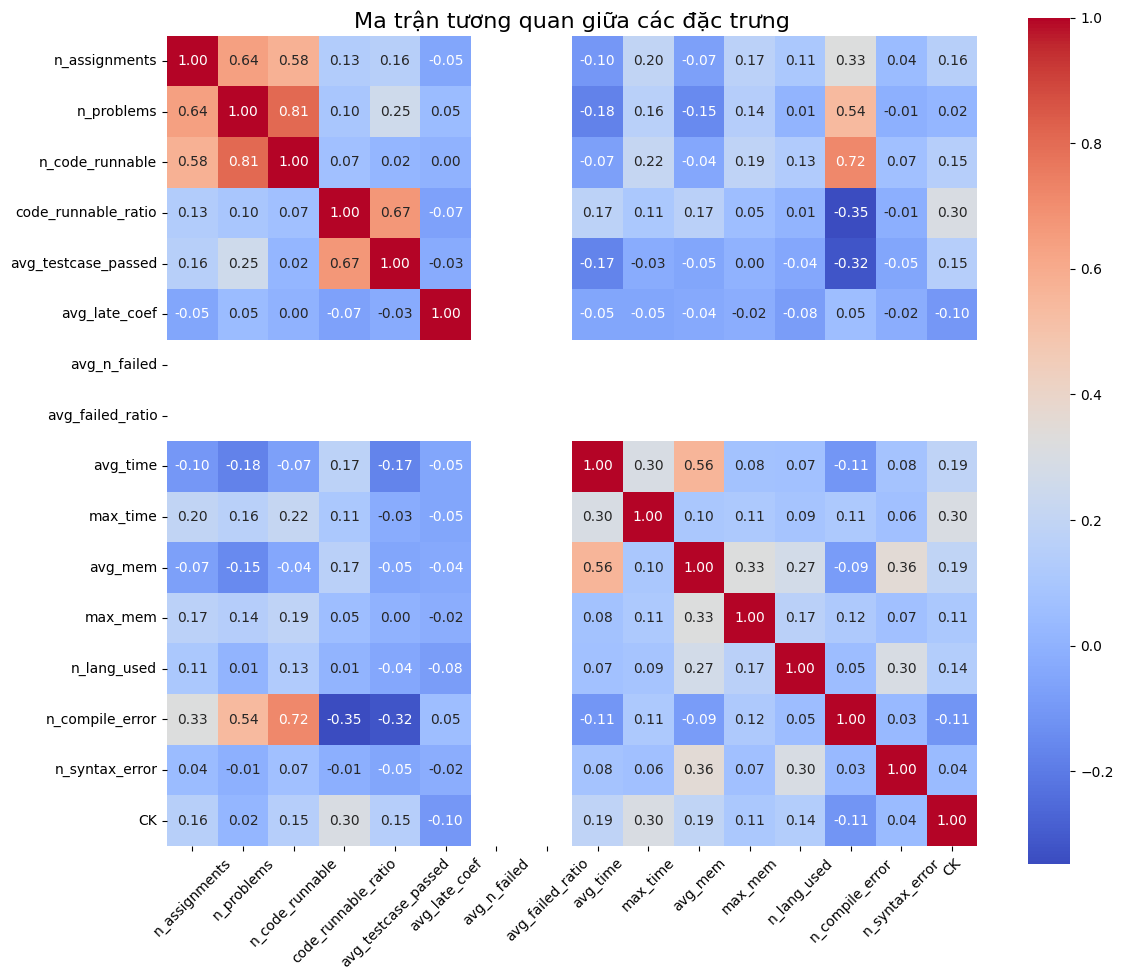

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Tính ma trận tương quan
corr_matrix = df_merged.corr(numeric_only=True)

# Vẽ biểu đồ heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title("Ma trận tương quan giữa các đặc trưng", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [25]:
df_clean = df_merged.copy()

In [26]:
df_features = df_clean.drop(columns=['mssv'])  # thay 'mssv' bằng tên cột ID thực tế

### Vẽ boxplot (biểu đồ hộp) cho tất cả các đặc trưng

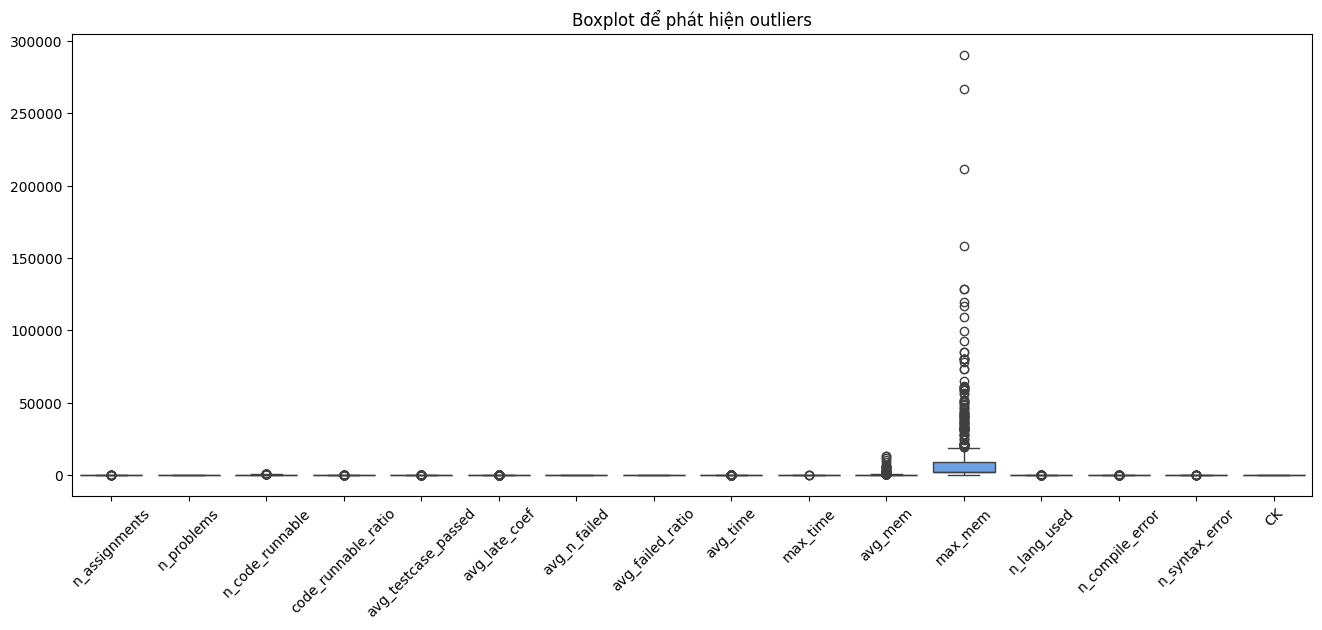

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 6))
sns.boxplot(data=df_features)
plt.xticks(rotation=45)
plt.title("Boxplot để phát hiện outliers")
plt.show()


### Plot cái ở trên

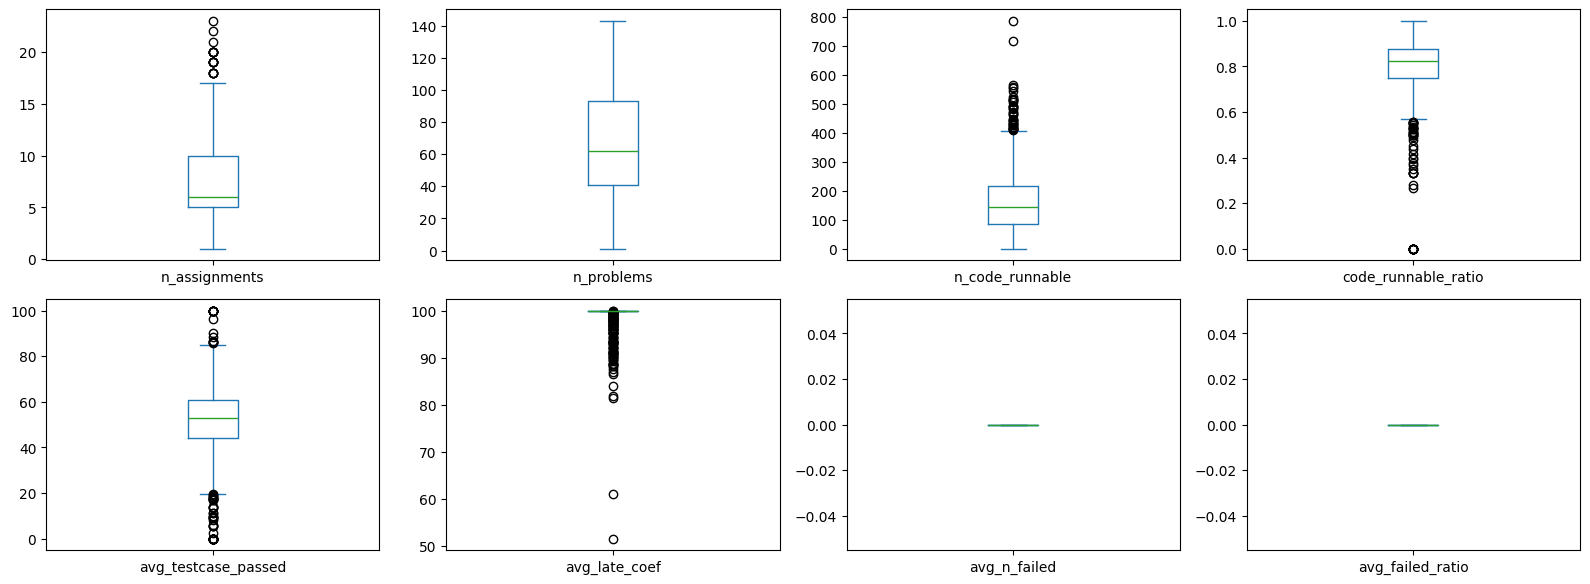

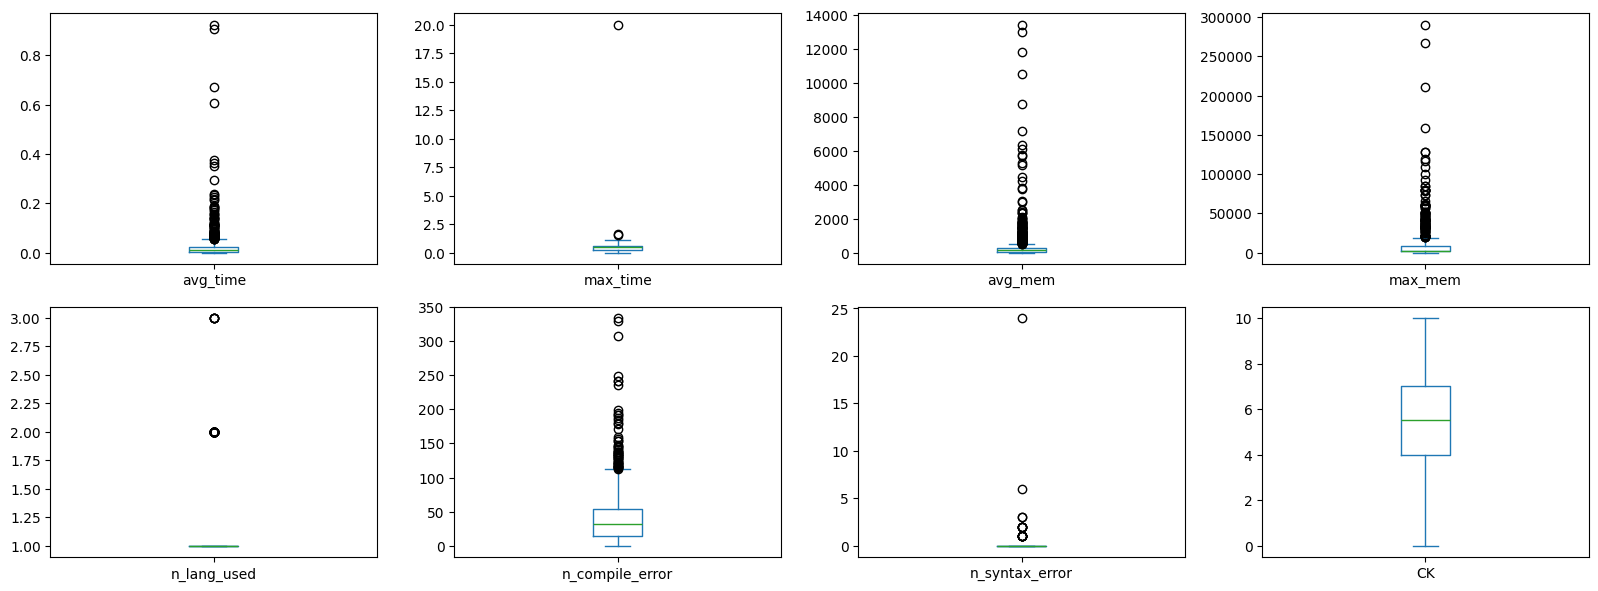

In [28]:
cols1 = ['n_assignments', 'n_problems', 'n_code_runnable', 'code_runnable_ratio',
         'avg_testcase_passed', 'avg_late_coef', 'avg_n_failed', 'avg_failed_ratio']
df_clean[cols1].plot(kind='box', subplots=True, layout=(2, 4), figsize=(16, 6), sharey=False)
plt.tight_layout()
plt.show()

cols2 = ['avg_time', 'max_time', 'avg_mem', 'max_mem',
         'n_lang_used', 'n_compile_error', 'n_syntax_error', 'CK']
df_clean[cols2].plot(kind='box', subplots=True, layout=(2, 4), figsize=(16, 6), sharey=False)
plt.tight_layout()
plt.show()


### Dùng log scale cho trục y để “nén” outlier

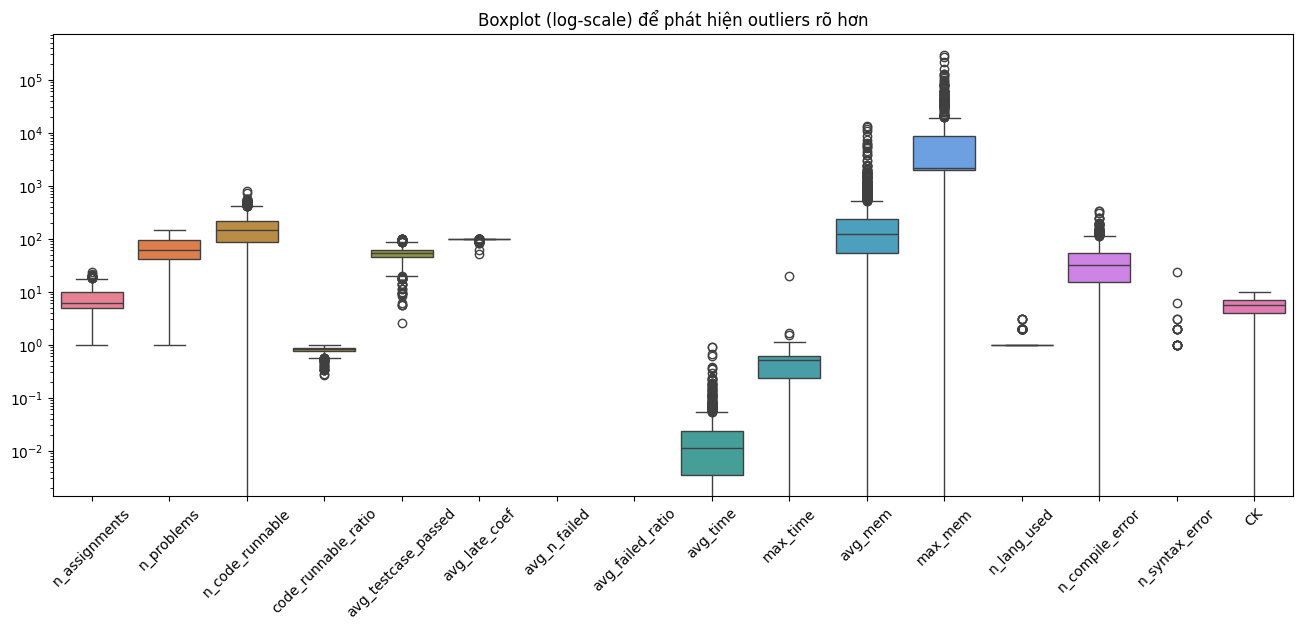

In [29]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
sns.boxplot(data=df_features)
plt.yscale("log")
plt.xticks(rotation=45)
plt.title("Boxplot (log-scale) để phát hiện outliers rõ hơn")
plt.show()


### Xem top giá trị lớn nhất ở cột outlier nặng

In [30]:
df_clean[['max_mem']].sort_values(by='max_mem', ascending=False).head(10)

,max_mem
1029,290291.542857
203,267104.342857
1320,211564.000000
268,158377.257143
273,128309.714286
860,128309.714286
97,119694.933333
486,116851.733333
1201,108968.800000
648,99640.000000


### Kiểm tra dòng có outlier

In [31]:
Q1 = df_clean['max_mem'].quantile(0.25)
Q3 = df_clean['max_mem'].quantile(0.75)
IQR = Q3 - Q1

outlier_threshold = Q3 + 1.5 * IQR

outliers = df_clean[df_clean['max_mem'] > outlier_threshold]
print(f"Số dòng outlier max_mem: {len(outliers)}")


Số dòng outlier max_mem: 114


### Vẽ từng cột một (nếu quá nhiều cột hoặc muốn chi tiết)

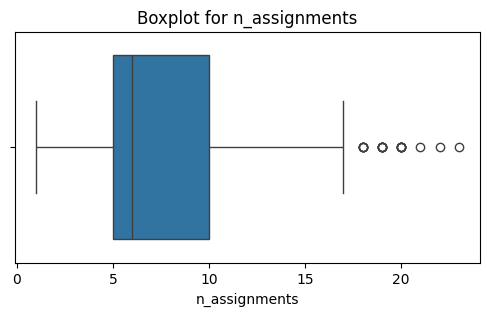

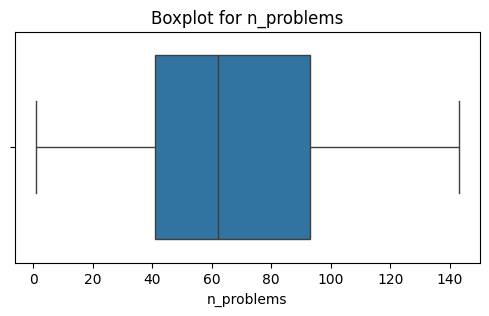

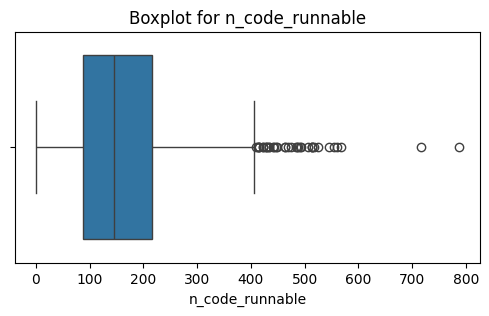

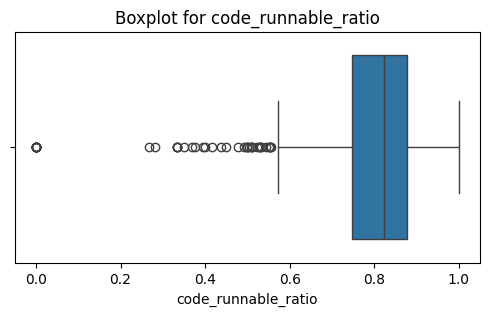

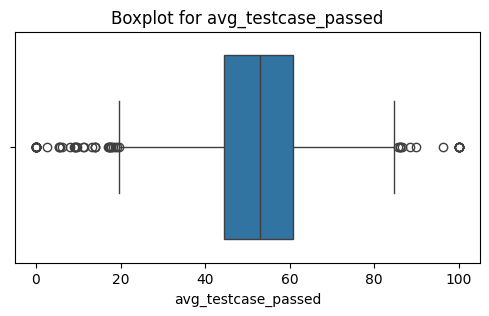

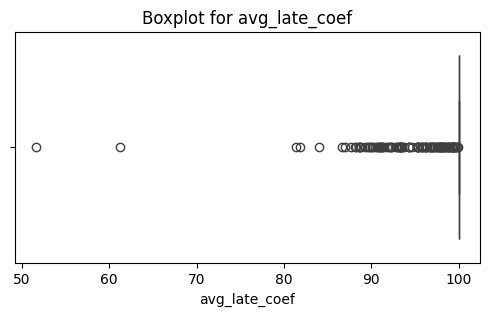

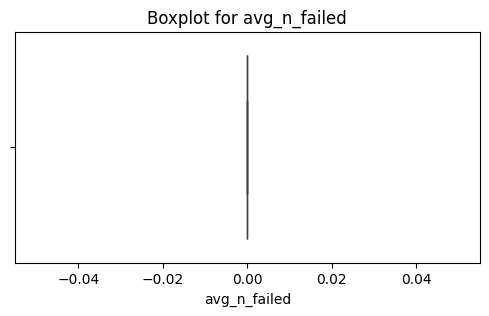

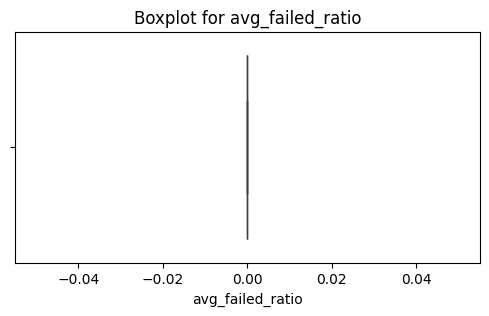

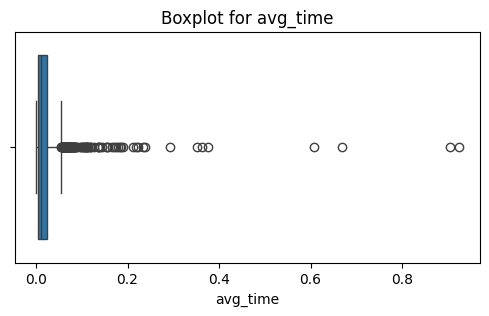

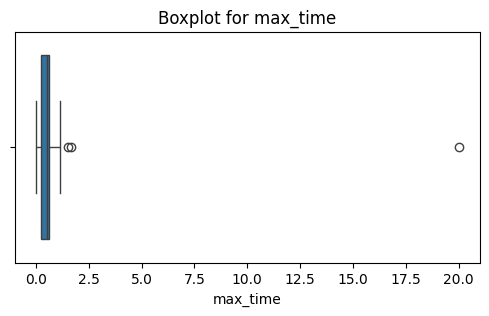

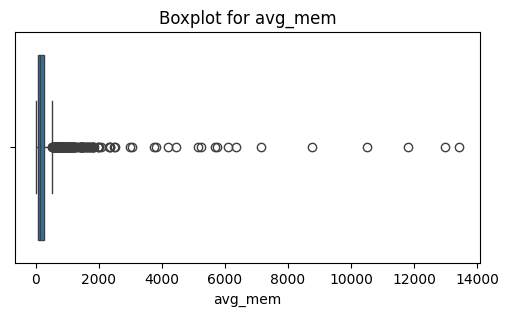

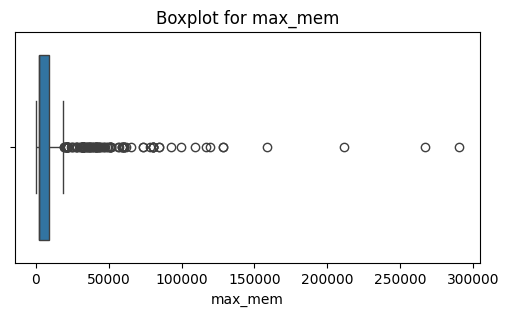

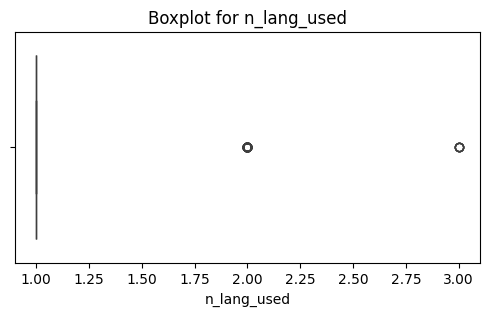

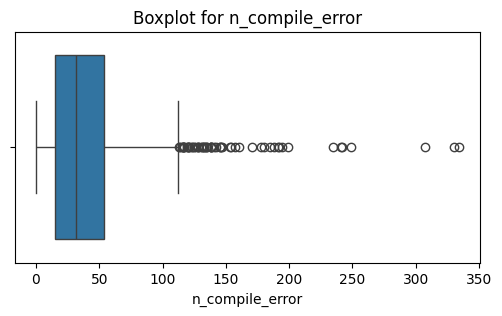

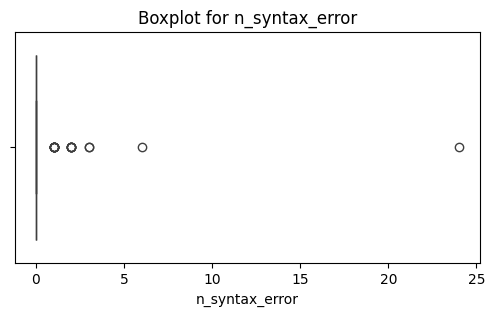

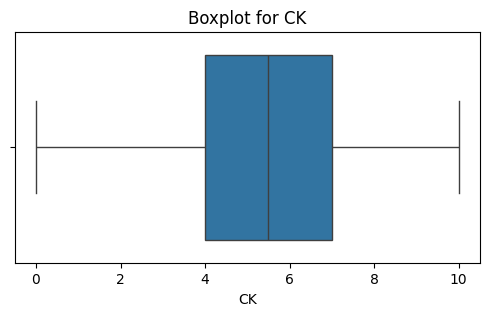

In [32]:
for col in df_features.columns:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df_features[col])
    plt.title(f"Boxplot for {col}")
    plt.show()


### Vẽ phân phối (histogram) kèm outlier

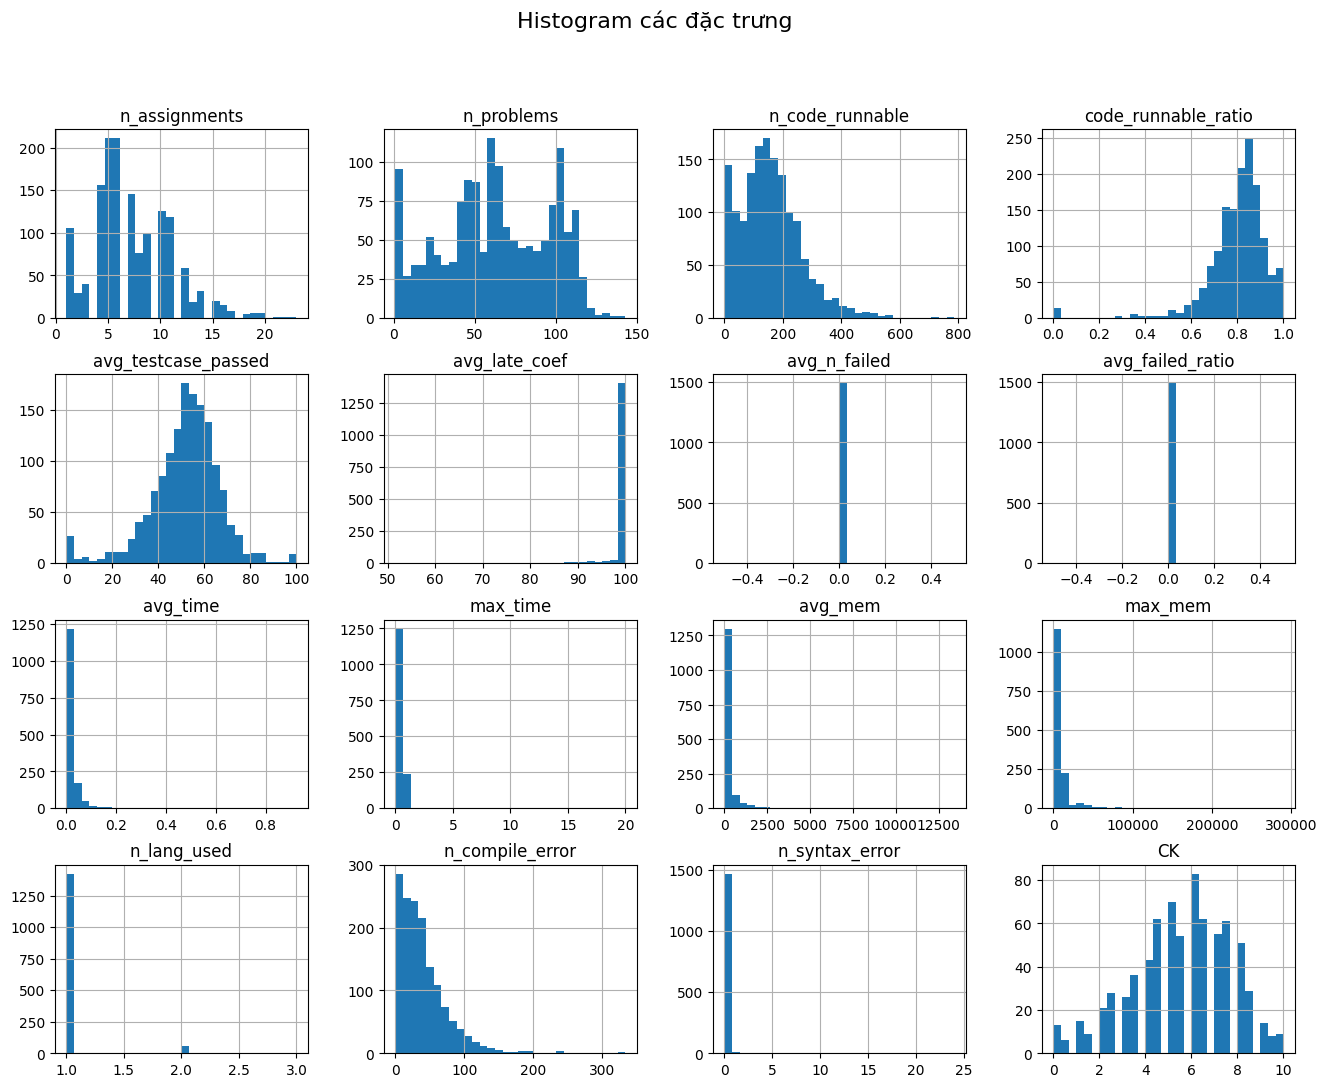

In [33]:
df_features.hist(bins=30, figsize=(16, 12))
plt.suptitle("Histogram các đặc trưng", fontsize=16)
plt.show()


### Dùng z-score để đánh dấu outlier

In [34]:
from scipy.stats import zscore

z_scores = df_features.apply(zscore)
outliers = (abs(z_scores) > 3)  # giá trị tuyệt đối lớn hơn 3 là nghi ngờ
print(outliers.sum())  # đếm số lượng outlier trên từng cột


n_assignments          15
n_problems              0
n_code_runnable        18
code_runnable_ratio    25
avg_testcase_passed    39
avg_late_coef          34
avg_n_failed            0
avg_failed_ratio        0
avg_time               18
max_time                1
avg_mem                18
max_mem                23
n_lang_used            64
n_compile_error        20
n_syntax_error          4
CK                      0
dtype: int64


### LOẠI BỎ ĐẶC TRƯNG SAU KHI TRAIN LẦN TRƯỚC ĐÓ

In [35]:
# df_clean = df_clean.drop(columns=['avg_failed_ratio'])
# df_clean = df_clean.drop(columns=['avg_n_failed'])
# df_clean = df_clean.drop(columns=['n_lang_used'])
# df_clean = df_clean.drop(columns=['n_syntax_error'])
# df_clean = df_clean.drop(columns=['avg_late_coef'])
# df_clean = df_clean.drop(columns=['n_problems'])

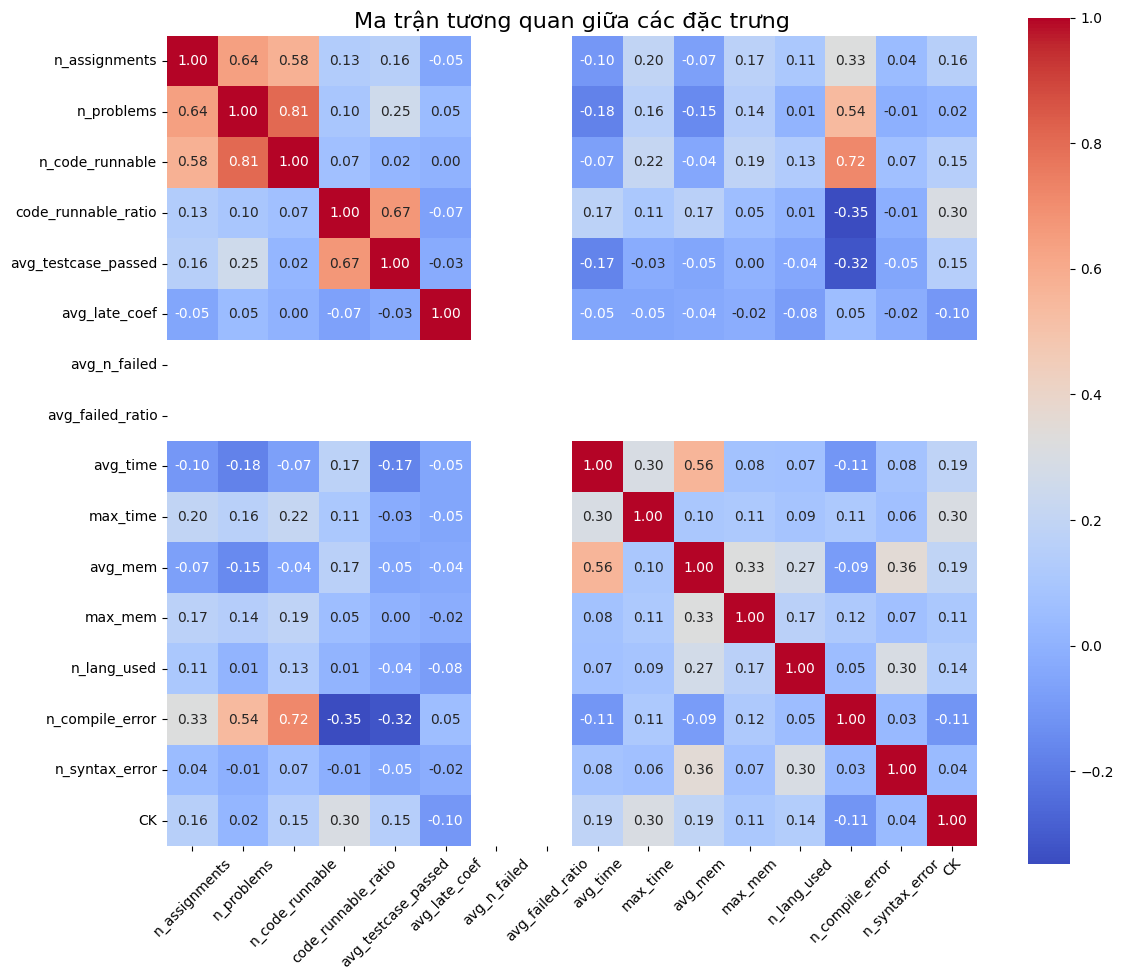

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Tính ma trận tương quan
corr_matrix = df_clean.corr(numeric_only=True)

# Vẽ biểu đồ heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title("Ma trận tương quan giữa các đặc trưng", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Chia dữ liệu thành tập train / test

In [37]:
train_df = df_clean[df_clean['CK'].notna()]
test_df = df_clean[df_clean['CK'].isna()]

X_train = train_df.drop(columns=['mssv', 'CK'])
y_train = train_df['CK']
X_test = test_df.drop(columns=['mssv', 'CK'])

In [38]:
X_train.describe()

,n_assignments,n_problems,n_code_runnable,code_runnable_ratio,avg_testcase_passed,avg_late_coef,avg_n_failed,avg_failed_ratio,avg_time,max_time,avg_mem,max_mem,n_lang_used,n_compile_error,n_syntax_error
count,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.0,755.0,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000
mean,7.494040,64.622517,165.076821,0.799654,51.269708,99.574207,0.0,0.0,0.021162,0.449540,248.805801,7405.353592,1.046358,42.811921,0.015894
std,3.761582,32.704193,108.111309,0.128960,14.773228,2.466515,0.0,0.0,0.051522,0.283190,638.844111,17354.564431,0.228527,39.315079,0.241045
min,1.000000,1.000000,0.000000,0.000000,0.000000,51.612903,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,5.000000,43.000000,91.000000,0.745502,44.230177,100.000000,0.0,0.0,0.002941,0.232159,54.316809,1984.000000,1.000000,17.000000,0.000000
50%,7.000000,64.000000,153.000000,0.816327,52.798246,100.000000,0.0,0.0,0.010777,0.525000,120.475222,2128.000000,1.000000,34.000000,0.000000
75%,10.000000,94.000000,226.000000,0.873624,60.034670,100.000000,0.0,0.0,0.022797,0.604615,232.006492,8279.666667,1.000000,58.500000,0.000000
max,23.000000,131.000000,787.000000,1.000000,100.000000,100.000000,0.0,0.0,0.923846,1.037083,13423.358025,267104.342857,3.000000,334.000000,6.000000


In [39]:
# from sklearn.preprocessing import RobustScaler

# # Giả sử X là DataFrame đầu vào
# scaler = RobustScaler()
# X_train[['avg_mem', 'max_mem']] = scaler.fit_transform(X_train[['avg_mem', 'max_mem']])
# X_test[['avg_mem', 'max_mem']] = scaler.fit_transform(X_test[['avg_mem', 'max_mem']])

In [40]:
X_train.describe()

,n_assignments,n_problems,n_code_runnable,code_runnable_ratio,avg_testcase_passed,avg_late_coef,avg_n_failed,avg_failed_ratio,avg_time,max_time,avg_mem,max_mem,n_lang_used,n_compile_error,n_syntax_error
count,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.0,755.0,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000
mean,7.494040,64.622517,165.076821,0.799654,51.269708,99.574207,0.0,0.0,0.021162,0.449540,248.805801,7405.353592,1.046358,42.811921,0.015894
std,3.761582,32.704193,108.111309,0.128960,14.773228,2.466515,0.0,0.0,0.051522,0.283190,638.844111,17354.564431,0.228527,39.315079,0.241045
min,1.000000,1.000000,0.000000,0.000000,0.000000,51.612903,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,5.000000,43.000000,91.000000,0.745502,44.230177,100.000000,0.0,0.0,0.002941,0.232159,54.316809,1984.000000,1.000000,17.000000,0.000000
50%,7.000000,64.000000,153.000000,0.816327,52.798246,100.000000,0.0,0.0,0.010777,0.525000,120.475222,2128.000000,1.000000,34.000000,0.000000
75%,10.000000,94.000000,226.000000,0.873624,60.034670,100.000000,0.0,0.0,0.022797,0.604615,232.006492,8279.666667,1.000000,58.500000,0.000000
max,23.000000,131.000000,787.000000,1.000000,100.000000,100.000000,0.0,0.0,0.923846,1.037083,13423.358025,267104.342857,3.000000,334.000000,6.000000


In [41]:
X_test.describe()

,n_assignments,n_problems,n_code_runnable,code_runnable_ratio,avg_testcase_passed,avg_late_coef,avg_n_failed,avg_failed_ratio,avg_time,max_time,avg_mem,max_mem,n_lang_used,n_compile_error,n_syntax_error
count,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.0,734.0,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000
mean,6.963215,60.544959,151.046322,0.803632,52.290215,99.516685,0.0,0.0,0.023052,0.481891,354.139514,7620.025420,1.046322,37.202997,0.061308
std,3.771438,33.516953,100.994512,0.132571,15.354874,2.337878,0.0,0.0,0.050681,0.775977,1040.130243,18528.753022,0.222920,33.119008,0.916903
min,1.000000,1.000000,0.000000,0.000000,0.000000,61.172161,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,4.000000,37.000000,79.250000,0.750000,44.609357,100.000000,0.0,0.0,0.003876,0.261167,52.145307,1984.000000,1.000000,14.000000,0.000000
50%,6.000000,59.000000,140.500000,0.827152,53.455089,100.000000,0.0,0.0,0.011778,0.525000,125.693428,2128.000000,1.000000,31.000000,0.000000
75%,10.000000,90.000000,204.750000,0.878602,61.541848,100.000000,0.0,0.0,0.025097,0.603750,247.006928,9039.600000,1.000000,50.000000,0.000000
max,22.000000,143.000000,717.000000,1.000000,100.000000,100.000000,0.0,0.0,0.904722,20.010000,12985.296296,290291.542857,3.000000,330.000000,24.000000


### Huấn luyện

In [42]:
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

model = CatBoostRegressor(verbose=0, random_state=42)
model.fit(X_train, y_train)

### Đánh giá trên tập huấn luyện

In [43]:
y_pred_train = model.predict(X_train)
print("R^2 score trên tập huấn luyện:", r2_score(y_train, y_pred_train))

R^2 score trên tập huấn luyện: 0.9075556986742194


### Dự đoán kết quả trên tập test

In [44]:
test_df['CK'] = model.predict(X_test)

C:\Users\MrBeast\AppData\Local\Temp\ipykernel_16968\158634260.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['CK'] = model.predict(X_test)


### Lưu kết quả điểm vào file csv để nộp

In [45]:
submission = test_df[['mssv', 'CK']]
submission[['mssv', 'CK']].to_csv('result.csv', index=False, header=False, encoding='utf-8')

### Lưu bộ siêu tham số tốt nhất

In [46]:
joblib.dump(model, 'best_model.pkl')

['best_model.pkl']

### In ra bộ siêu tham số tốt nhất

In [47]:
model = joblib.load('best_model.pkl')

print(model)

# Xem các tham số mô hình
print(model.get_params())

{'loss_function': 'RMSE', 'verbose': 0, 'random_state': 42}


### In ra các đặc trưng có ảnh hưởng, đóng góp vào kết quả dự đoán điểm

In [48]:
print(model.feature_importances_)

[7.74330282e+00 1.06021619e+01 9.28152693e+00 1.26022609e+01
 1.15231394e+01 1.05331050e+00 0.00000000e+00 0.00000000e+00
 7.52015133e+00 8.67634343e+00 1.65951104e+01 6.16329630e+00
 3.43103148e-01 7.88116544e+00 1.51275580e-02]


### Vẽ biểu đồ các đặc trưng trên

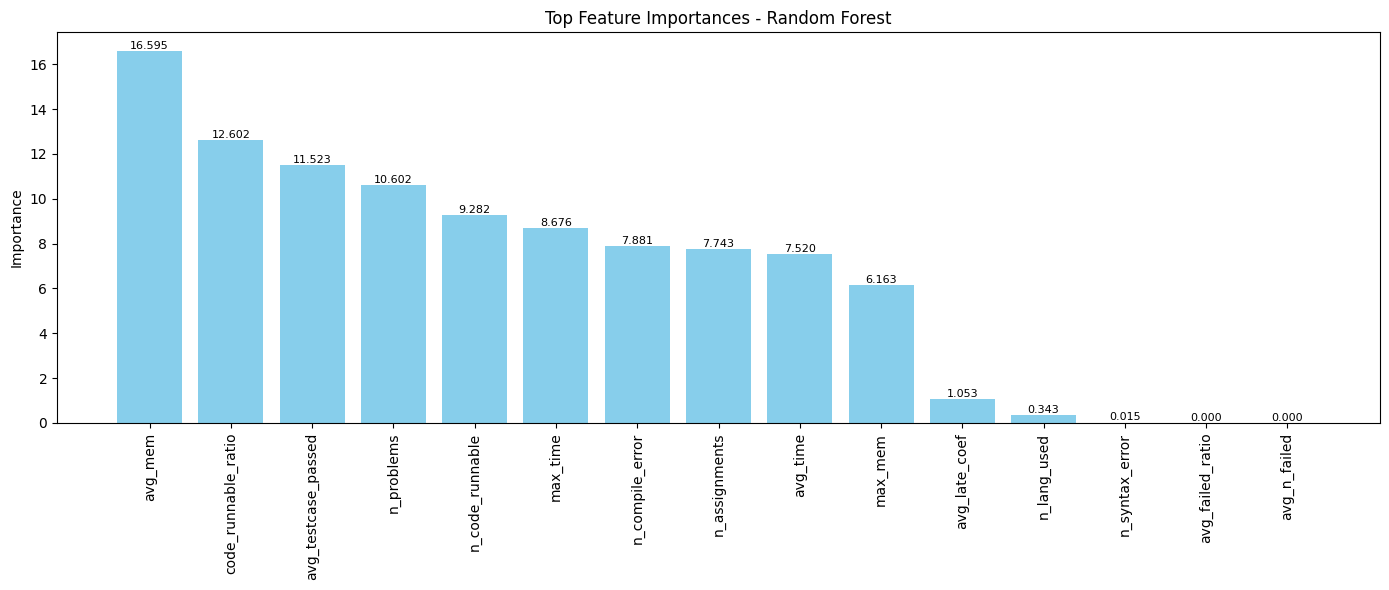

In [49]:
importances = model.feature_importances_
feature_names = X_train.columns

indices = np.argsort(importances)[::-1]
sorted_importances = importances[indices]
sorted_features = feature_names[indices]

top_k = min(20, len(importances))
sorted_importances = sorted_importances[:top_k]
sorted_features = sorted_features[:top_k]

# Vẽ
plt.figure(figsize=(14, 6))
bars = plt.bar(range(top_k), sorted_importances, color='skyblue', align='center')
plt.xticks(range(top_k), sorted_features, rotation=90)
plt.title('Top Feature Importances - Random Forest')
plt.ylabel('Importance')
plt.tight_layout()

# Ghi nhãn số
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + 0.005, f'{height:.3f}', 
             ha='center', va='bottom', fontsize=8)

plt.show()
